## Redrob Hackathon: Evaluation and Ablation

### What this notebook does
This notebook evaluates the retrieval and reranking pipeline, checks trap behavior, and compares alternative scoring variants.

### Why this notebook is needed
The final submission notebook produces the CSV.
This notebook helps us understand whether the ranking pipeline is actually behaving well, whether the shortlist is clean, and which signals are most useful.

In [1]:
!pip install -q pandas numpy matplotlib pyarrow

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
PROJECT_DIR = Path("/content/drive/MyDrive/Redrob_Hackathon")
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
OUTPUTS_DIR = PROJECT_DIR / "outputs"

FEATURES_PATH = ARTIFACTS_DIR / "candidate_features.parquet"
RETRIEVAL_PATH = ARTIFACTS_DIR / "candidate_retrieval_shortlist.parquet"
RERANK_PATH = ARTIFACTS_DIR / "reranked_candidates.parquet"
FINAL_SHORTLIST_PATH = ARTIFACTS_DIR / "final_shortlist_for_reasoning.parquet"
JD_COMPASS_PATH = ARTIFACTS_DIR / "jd_compass.json"

In [5]:
print("Features exists:", FEATURES_PATH.exists())
print("Retrieval exists:", RETRIEVAL_PATH.exists())
print("Rerank exists:", RERANK_PATH.exists())
print("Final shortlist exists:", FINAL_SHORTLIST_PATH.exists())
print("JD compass exists:", JD_COMPASS_PATH.exists())

Features exists: True
Retrieval exists: True
Rerank exists: True
Final shortlist exists: True
JD compass exists: True


In [6]:
features_df = pd.read_parquet(FEATURES_PATH)
retrieval_df = pd.read_parquet(RETRIEVAL_PATH)
rerank_df = pd.read_parquet(RERANK_PATH)
final_shortlist_df = pd.read_parquet(FINAL_SHORTLIST_PATH)

with open(JD_COMPASS_PATH, "r", encoding="utf-8") as f:
    jd_compass = json.load(f)

In [7]:
print("features_df shape:", features_df.shape)
print("retrieval_df shape:", retrieval_df.shape)
print("rerank_df shape:", rerank_df.shape)
print("final_shortlist_df shape:", final_shortlist_df.shape)

features_df shape: (100000, 53)
retrieval_df shape: (1500, 58)
rerank_df shape: (1500, 120)
final_shortlist_df shape: (100, 120)


In [12]:
def pick_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"None of these columns were found: {candidates}")


# -----------------------------
# Columns for retrieval_df
# -----------------------------
retrieval_id_col = pick_column(
    retrieval_df,
    ["candidate_id"]
)

retrieval_title_col = pick_column(
    retrieval_df,
    ["current_title", "current_title_retrieval", "current_title_full"]
)

retrieval_years_col = pick_column(
    retrieval_df,
    ["years_of_experience", "years_of_experience_retrieval", "years_of_experience_full"]
)

retrieval_score_col = pick_column(
    retrieval_df,
    ["retrieval_stage_score", "rrf_score", "hybrid_score", "bm25_score"]
)

retrieval_role_col = pick_column(
    retrieval_df,
    ["role_evidence_score", "role_evidence_score_retrieval", "role_evidence_score_full"]
)

retrieval_risk_col = pick_column(
    retrieval_df,
    ["total_risk_score", "total_risk_score_retrieval", "total_risk_score_full"]
)

retrieval_avail_col = pick_column(
    retrieval_df,
    ["availability_strength", "availability_strength_retrieval", "availability_strength_full"]
)


# -----------------------------
# Columns for rerank_df
# -----------------------------
rerank_id_col = pick_column(
    rerank_df,
    ["candidate_id"]
)

rerank_title_col = pick_column(
    rerank_df,
    ["current_title_full", "current_title_retrieval", "current_title"]
)

rerank_years_col = pick_column(
    rerank_df,
    ["years_of_experience_full", "years_of_experience_retrieval", "years_of_experience"]
)

rerank_location_col = pick_column(
    rerank_df,
    ["location_full", "location_retrieval", "location"]
)

rerank_score_col = pick_column(
    rerank_df,
    ["final_rerank_score", "cross_encoder_score", "retrieval_stage_score"]
)

rerank_trap_col = pick_column(
    rerank_df,
    ["trap_score"]
)

rerank_risk_col = pick_column(
    rerank_df,
    ["total_risk_score_full", "total_risk_score_retrieval", "total_risk_score"]
)

rerank_role_col = pick_column(
    rerank_df,
    ["role_evidence_score_full", "role_evidence_score_retrieval", "role_evidence_score"]
)

rerank_avail_col = pick_column(
    rerank_df,
    ["availability_strength_full", "availability_strength_retrieval", "availability_strength"]
)


# -----------------------------
# Columns for final_shortlist_df
# -----------------------------
final_id_col = pick_column(
    final_shortlist_df,
    ["candidate_id"]
)

final_title_col = pick_column(
    final_shortlist_df,
    ["current_title_full", "current_title_retrieval", "current_title"]
)

final_years_col = pick_column(
    final_shortlist_df,
    ["years_of_experience_full", "years_of_experience_retrieval", "years_of_experience"]
)

final_score_col = pick_column(
    final_shortlist_df,
    ["final_rerank_score", "cross_encoder_score", "retrieval_stage_score"]
)

final_role_col = pick_column(
    final_shortlist_df,
    ["role_evidence_score_full", "role_evidence_score_retrieval", "role_evidence_score"]
)

final_trap_col = pick_column(
    final_shortlist_df,
    ["trap_score"]
)

final_risk_col = pick_column(
    final_shortlist_df,
    ["total_risk_score_full", "total_risk_score_retrieval", "total_risk_score"]
)

final_avail_col = pick_column(
    final_shortlist_df,
    ["availability_strength_full", "availability_strength_retrieval", "availability_strength"]
)


print("Retrieval title column:", retrieval_title_col)
print("Retrieval years column:", retrieval_years_col)

print("Rerank title column:", rerank_title_col)
print("Rerank years column:", rerank_years_col)

print("Final shortlist title column:", final_title_col)
print("Final shortlist years column:", final_years_col)

Retrieval title column: current_title
Retrieval years column: years_of_experience
Rerank title column: current_title_full
Rerank years column: years_of_experience_full
Final shortlist title column: current_title_full
Final shortlist years column: years_of_experience_full


In [13]:
def summarize_stage(df, score_col, label):
    return pd.Series({
        "stage": label,
        "rows": len(df),
        "score_min": float(df[score_col].min()),
        "score_mean": float(df[score_col].mean()),
        "score_max": float(df[score_col].max()),
        "avg_role_evidence": float(df.get(retrieval_role_col, pd.Series([np.nan]*len(df))).mean()),
        "avg_risk": float(df.get(retrieval_risk_col, pd.Series([np.nan]*len(df))).mean()),
        "avg_availability": float(df.get(retrieval_avail_col, pd.Series([np.nan]*len(df))).mean()),
    })

stage_summary = pd.DataFrame([
    summarize_stage(retrieval_df, retrieval_score_col, "retrieval"),
    summarize_stage(rerank_df, rerank_score_col, "rerank"),
    summarize_stage(final_shortlist_df, rerank_score_col, "final_shortlist"),
])

display(stage_summary)

,stage,rows,score_min,score_mean,score_max,avg_role_evidence,avg_risk,avg_availability
0,retrieval,1500,5.277499,7.134219,17.198684,13.222667,0.81,36.036282
1,rerank,1500,-6.523939,24.622034,78.016651,NaN,NaN,NaN
2,final_shortlist,100,47.597959,57.433145,78.016651,NaN,NaN,NaN


In [14]:
print("Top retrieval candidates:")

display(
    retrieval_df[
        [
            retrieval_id_col,
            retrieval_title_col,
            retrieval_years_col,
            retrieval_score_col,
            retrieval_role_col,
            retrieval_risk_col
        ]
    ].head(20)
)


print("Top reranked candidates:")

display(
    rerank_df[
        [
            rerank_id_col,
            rerank_title_col,
            rerank_years_col,
            rerank_score_col,
            rerank_role_col,
            rerank_trap_col,
            rerank_risk_col
        ]
    ].head(20)
)


print("Top final shortlist candidates:")

display(
    final_shortlist_df[
        [
            final_id_col,
            final_title_col,
            final_years_col,
            final_score_col,
            final_role_col,
            final_trap_col,
            final_risk_col
        ]
    ].head(20)
)

Top retrieval candidates:


,candidate_id,current_title,years_of_experience,retrieval_stage_score,role_evidence_score,total_risk_score
0,CAND_0086022,Senior Applied Scientist,5.3,17.198684,27.5,2
1,CAND_0055905,Senior Machine Learning Engineer,8.1,14.729931,31.5,1
2,CAND_0046525,Senior Machine Learning Engineer,6.1,14.505055,27.0,0
3,CAND_0005649,Senior Data Scientist,7.4,14.447821,32.5,0
4,CAND_0069905,Applied ML Engineer,6.6,13.971742,32.0,0
5,CAND_0079387,AI Engineer,6.9,13.921192,32.0,2
6,CAND_0081846,Lead AI Engineer,6.7,13.827415,31.5,2
7,CAND_0055992,AI Engineer,16.9,13.480170,27.0,0
8,CAND_0046064,Senior NLP Engineer,8.9,13.453691,25.5,0
9,CAND_0040887,Machine Learning Engineer,4.7,13.451692,26.8,0


Top reranked candidates:


,candidate_id,current_title_full,years_of_experience_full,final_rerank_score,role_evidence_score_full,trap_score,total_risk_score_full
0,CAND_0055905,Senior Machine Learning Engineer,8.1,78.016651,31.5,0.0,1
1,CAND_0005649,Senior Data Scientist,7.4,76.579591,32.5,0.0,0
2,CAND_0081846,Lead AI Engineer,6.7,74.986441,31.5,0.0,2
3,CAND_0086022,Senior Applied Scientist,5.3,72.848459,27.5,0.0,2
4,CAND_0069905,Applied ML Engineer,6.6,72.572914,32.0,0.0,0
5,CAND_0046525,Senior Machine Learning Engineer,6.1,71.782399,27.0,0.0,0
6,CAND_0077337,Staff Machine Learning Engineer,7.0,70.739877,28.5,0.0,2
7,CAND_0044883,AI Engineer,6.3,69.618009,30.0,0.0,0
8,CAND_0083307,Search Engineer,7.8,67.680995,32.0,0.0,3
9,CAND_0079387,AI Engineer,6.9,67.169423,32.0,0.0,2


Top final shortlist candidates:


,candidate_id,current_title_full,years_of_experience_full,final_rerank_score,role_evidence_score_full,trap_score,total_risk_score_full
0,CAND_0055905,Senior Machine Learning Engineer,8.1,78.016651,31.5,0.0,1
1,CAND_0005649,Senior Data Scientist,7.4,76.579591,32.5,0.0,0
2,CAND_0081846,Lead AI Engineer,6.7,74.986441,31.5,0.0,2
3,CAND_0086022,Senior Applied Scientist,5.3,72.848459,27.5,0.0,2
4,CAND_0069905,Applied ML Engineer,6.6,72.572914,32.0,0.0,0
5,CAND_0046525,Senior Machine Learning Engineer,6.1,71.782399,27.0,0.0,0
6,CAND_0077337,Staff Machine Learning Engineer,7.0,70.739877,28.5,0.0,2
7,CAND_0044883,AI Engineer,6.3,69.618009,30.0,0.0,0
8,CAND_0083307,Search Engineer,7.8,67.680995,32.0,0.0,3
9,CAND_0079387,AI Engineer,6.9,67.169423,32.0,0.0,2


In [15]:
retrieval_top100 = set(retrieval_df["candidate_id"].head(100))
rerank_top100 = set(rerank_df["candidate_id"].head(100))
final_top100 = set(final_shortlist_df["candidate_id"].head(100))

print("Retrieval top100 ∩ Rerank top100:", len(retrieval_top100 & rerank_top100))
print("Retrieval top100 ∩ Final top100:", len(retrieval_top100 & final_top100))
print("Rerank top100 ∩ Final top100:", len(rerank_top100 & final_top100))

Retrieval top100 ∩ Rerank top100: 85
Retrieval top100 ∩ Final top100: 85
Rerank top100 ∩ Final top100: 100


In [16]:
print("Trap score distribution:")
display(rerank_df[rerank_trap_col].value_counts().sort_index())

print("\nTrap score summary:")
display(rerank_df[rerank_trap_col].describe())

Trap score distribution:


,count
trap_score,
0.0,1421
1.5,58
2.0,19
3.5,2



Trap score summary:


,trap_score
count,1500.000000
mean,0.088000
std,0.382562
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,3.500000


In [17]:
high_risk_threshold = 4
high_trap_threshold = 2.5

final_top100 = rerank_df.head(100).copy()

high_risk_count = (final_top100[rerank_risk_col] >= high_risk_threshold).sum()
high_trap_count = (final_top100[rerank_trap_col] >= high_trap_threshold).sum()

print("High-risk candidates in final top100:", high_risk_count)
print("High-trap candidates in final top100:", high_trap_count)

display(
    final_top100[
        [
            "candidate_id",
            title_col,
            years_col,
            rerank_score_col,
            rerank_role_col,
            rerank_trap_col,
            rerank_risk_col
        ]
    ].head(20)
)

High-risk candidates in final top100: 1
High-trap candidates in final top100: 1


,candidate_id,current_title_retrieval,years_of_experience_full,final_rerank_score,role_evidence_score_full,trap_score,total_risk_score_full
0,CAND_0055905,Senior Machine Learning Engineer,8.1,78.016651,31.5,0.0,1
1,CAND_0005649,Senior Data Scientist,7.4,76.579591,32.5,0.0,0
2,CAND_0081846,Lead AI Engineer,6.7,74.986441,31.5,0.0,2
3,CAND_0086022,Senior Applied Scientist,5.3,72.848459,27.5,0.0,2
4,CAND_0069905,Applied ML Engineer,6.6,72.572914,32.0,0.0,0
5,CAND_0046525,Senior Machine Learning Engineer,6.1,71.782399,27.0,0.0,0
6,CAND_0077337,Staff Machine Learning Engineer,7.0,70.739877,28.5,0.0,2
7,CAND_0044883,AI Engineer,6.3,69.618009,30.0,0.0,0
8,CAND_0083307,Search Engineer,7.8,67.680995,32.0,0.0,3
9,CAND_0079387,AI Engineer,6.9,67.169423,32.0,0.0,2


In [18]:
suspicious_top = final_top100.sort_values(
    by=[rerank_trap_col, rerank_risk_col],
    ascending=False
).head(20)

display(
    suspicious_top[
        [
            "candidate_id",
            title_col,
            years_col,
            location_col,
            rerank_score_col,
            rerank_trap_col,
            rerank_risk_col
        ]
    ]
)

,candidate_id,current_title_retrieval,years_of_experience_full,location_full,final_rerank_score,trap_score,total_risk_score_full
29,CAND_0041611,Staff Machine Learning Engineer,6.4,Austin,60.294009,3.5,5
36,CAND_0039754,Senior Applied Scientist,16.2,"Indore, Madhya Pradesh",58.542081,2.0,2
19,CAND_0055992,AI Engineer,16.9,Sydney,63.126666,2.0,0
48,CAND_0091534,AI Engineer,16.6,"Gurgaon, Haryana",56.246342,2.0,0
33,CAND_0033861,Senior NLP Engineer,8.0,"Vizag, Andhra Pradesh",59.074703,1.5,2
53,CAND_0094759,Lead AI Engineer,8.6,"Mumbai, Maharashtra",55.404588,1.5,2
8,CAND_0083307,Search Engineer,7.8,"Vizag, Andhra Pradesh",67.680995,0.0,3
15,CAND_0041568,Search Engineer,5.2,Sydney,65.042398,0.0,3
24,CAND_0005260,Senior NLP Engineer,5.2,"Chennai, Tamil Nadu",62.171526,0.0,3
25,CAND_0086151,Recommendation Systems Engineer,7.7,"Vizag, Andhra Pradesh",61.070014,0.0,3


In [33]:
TEAM_ID = "team_hehehe"

SUBMISSION_PATH = OUTPUTS_DIR / f"{TEAM_ID}.csv"

submission_df = pd.read_csv(SUBMISSION_PATH)

print("Submission shape:", submission_df.shape)
print("Submission columns:", submission_df.columns.tolist())

display(submission_df.head())

Submission shape: (100, 4)
Submission columns: ['candidate_id', 'rank', 'score', 'reasoning']


,candidate_id,rank,score,reasoning
0,CAND_0055905,1,1.000000,Senior Machine Learning Engineer with 8.1 year...
1,CAND_0005649,2,0.952757,Senior Data Scientist with 7.4 years looks lik...
2,CAND_0081846,3,0.900383,Lead AI Engineer with 6.7 years looks like a s...
3,CAND_0086022,4,0.830098,Senior Applied Scientist with 5.3 years looks ...
4,CAND_0069905,5,0.821040,Applied ML Engineer with 6.6 years looks like ...


In [34]:
reasoning_sample = submission_df.sample(10, random_state=42)[
    ["candidate_id", "rank", "score", "reasoning"]
].copy()

display(reasoning_sample)

print("Empty reasoning rows:", reasoning_sample["reasoning"].isna().sum())

print("\nReasoning length summary:")
display(reasoning_sample["reasoning"].str.len().describe())

,candidate_id,rank,score,reasoning
83,CAND_0064326,84,0.100159,Search Engineer with 7.6 years looks like a st...
53,CAND_0094759,54,0.256639,Lead AI Engineer with 8.6 years looks like a s...
70,CAND_0076831,71,0.162066,Search Engineer with 4.0 years is slightly jun...
45,CAND_0065195,46,0.311276,Search Engineer with 5.1 years looks like a st...
44,CAND_0052328,45,0.319670,Recommendation Systems Engineer with 6.5 years...
39,CAND_0057563,40,0.346499,NLP Engineer with 6.8 years looks like a stron...
22,CAND_0040887,23,0.494569,Machine Learning Engineer with 4.7 years is sl...
80,CAND_0030827,81,0.112411,Senior Data Scientist with 5.4 years looks lik...
10,CAND_0046064,11,0.632212,Senior NLP Engineer with 8.9 years looks like ...
0,CAND_0055905,1,1.000000,Senior Machine Learning Engineer with 8.1 year...


Empty reasoning rows: 0

Reasoning length summary:


,reasoning
count,10.000000
mean,362.600000
std,18.644034
min,324.000000
25%,353.750000
50%,367.000000
75%,373.000000
max,390.000000


In [26]:
ablation_df = rerank_df.copy()

# Variant 1: remove trap penalty
ablation_df["score_no_trap"] = (
    ablation_df[rerank_score_col] +
    ablation_df[rerank_trap_col] * 2.5
)

# Variant 2: remove risk penalty
ablation_df["score_no_risk"] = (
    ablation_df[rerank_score_col] +
    ablation_df[rerank_risk_col] * 0.5
)

# Variant 3: remove cross-encoder influence if available
if "cross_encoder_score" in ablation_df.columns:
    ablation_df["score_no_cross"] = (
        ablation_df[rerank_score_col] -
        ablation_df["cross_encoder_score"] * 3.0
    )
else:
    ablation_df["score_no_cross"] = np.nan

display(
    ablation_df[
        [
            "candidate_id",
            rerank_score_col,
            "score_no_trap",
            "score_no_risk",
            "score_no_cross"
        ]
    ].head(10)
)

,candidate_id,final_rerank_score,score_no_trap,score_no_risk,score_no_cross
0,CAND_0055905,78.016651,78.016651,78.516651,63.184189
1,CAND_0005649,76.579591,76.579591,76.579591,64.700810
2,CAND_0081846,74.986441,74.986441,75.986441,61.697673
3,CAND_0086022,72.848459,72.848459,73.848459,59.928684
4,CAND_0069905,72.572914,72.572914,72.572914,63.600731
5,CAND_0046525,71.782399,71.782399,71.782399,56.699449
6,CAND_0077337,70.739877,70.739877,71.739877,56.472632
7,CAND_0044883,69.618009,69.618009,69.618009,58.576241
8,CAND_0083307,67.680995,67.680995,69.180995,61.325026
9,CAND_0079387,67.169423,67.169423,68.169423,62.589450


In [27]:
top_base = set(ablation_df.sort_values(rerank_score_col, ascending=False).head(20)["candidate_id"])
top_no_trap = set(ablation_df.sort_values("score_no_trap", ascending=False).head(20)["candidate_id"])
top_no_risk = set(ablation_df.sort_values("score_no_risk", ascending=False).head(20)["candidate_id"])

print("Base vs no_trap overlap:", len(top_base & top_no_trap))
print("Base vs no_risk overlap:", len(top_base & top_no_risk))

if ablation_df["score_no_cross"].notna().any():
    top_no_cross = set(ablation_df.sort_values("score_no_cross", ascending=False).head(20)["candidate_id"])
    print("Base vs no_cross overlap:", len(top_base & top_no_cross))

Base vs no_trap overlap: 19
Base vs no_risk overlap: 18
Base vs no_cross overlap: 16


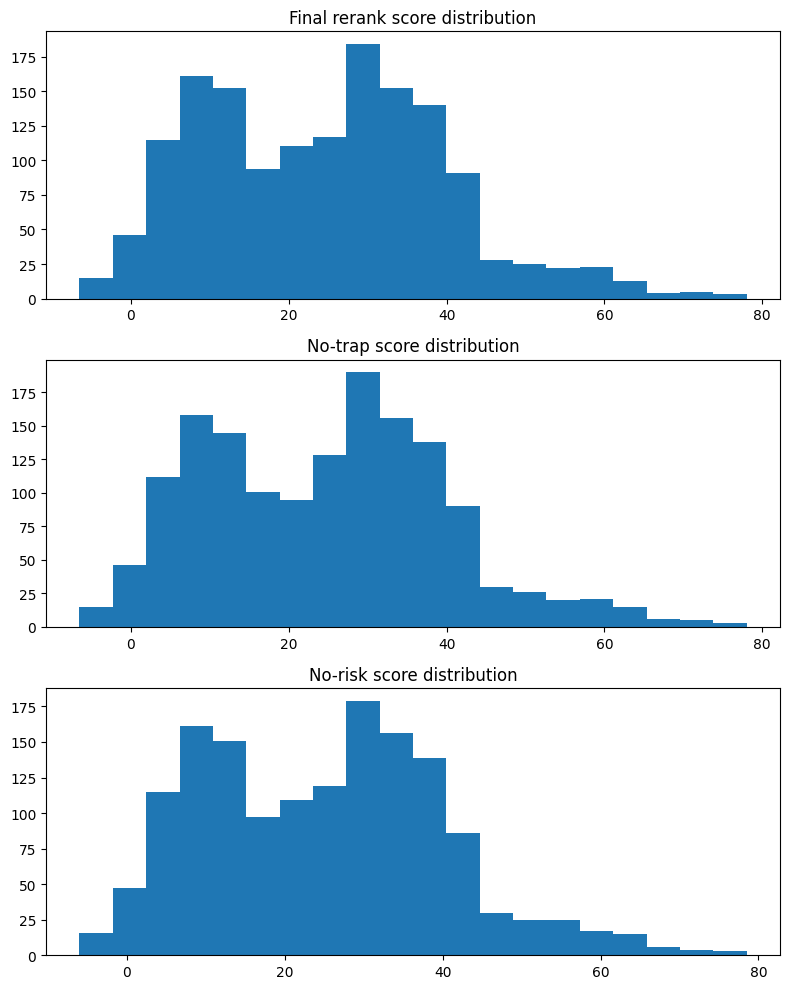

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

axes[0].hist(ablation_df[rerank_score_col].dropna(), bins=20)
axes[0].set_title("Final rerank score distribution")

axes[1].hist(ablation_df["score_no_trap"].dropna(), bins=20)
axes[1].set_title("No-trap score distribution")

axes[2].hist(ablation_df["score_no_risk"].dropna(), bins=20)
axes[2].set_title("No-risk score distribution")

plt.tight_layout()
plt.show()

In [29]:
for n in [10, 25, 50, 100]:
    print(f"\nTop {n} summary")
    chunk = rerank_df.head(n)
    display(
        chunk[
            [
                "candidate_id",
                title_col,
                years_col,
                rerank_score_col,
                rerank_role_col,
                rerank_trap_col,
                rerank_risk_col
            ]
        ].head(10)
    )
    print("Average score:", float(chunk[rerank_score_col].mean()))
    print("Average role evidence:", float(chunk[rerank_role_col].mean()))
    print("Average trap score:", float(chunk[rerank_trap_col].mean()))
    print("Average risk score:", float(chunk[rerank_risk_col].mean()))


Top 10 summary


,candidate_id,current_title_retrieval,years_of_experience_full,final_rerank_score,role_evidence_score_full,trap_score,total_risk_score_full
0,CAND_0055905,Senior Machine Learning Engineer,8.1,78.016651,31.5,0.0,1
1,CAND_0005649,Senior Data Scientist,7.4,76.579591,32.5,0.0,0
2,CAND_0081846,Lead AI Engineer,6.7,74.986441,31.5,0.0,2
3,CAND_0086022,Senior Applied Scientist,5.3,72.848459,27.5,0.0,2
4,CAND_0069905,Applied ML Engineer,6.6,72.572914,32.0,0.0,0
5,CAND_0046525,Senior Machine Learning Engineer,6.1,71.782399,27.0,0.0,0
6,CAND_0077337,Staff Machine Learning Engineer,7.0,70.739877,28.5,0.0,2
7,CAND_0044883,AI Engineer,6.3,69.618009,30.0,0.0,0
8,CAND_0083307,Search Engineer,7.8,67.680995,32.0,0.0,3
9,CAND_0079387,AI Engineer,6.9,67.169423,32.0,0.0,2


Average score: 72.19947580989121
Average role evidence: 30.45
Average trap score: 0.0
Average risk score: 1.2

Top 25 summary


,candidate_id,current_title_retrieval,years_of_experience_full,final_rerank_score,role_evidence_score_full,trap_score,total_risk_score_full
0,CAND_0055905,Senior Machine Learning Engineer,8.1,78.016651,31.5,0.0,1
1,CAND_0005649,Senior Data Scientist,7.4,76.579591,32.5,0.0,0
2,CAND_0081846,Lead AI Engineer,6.7,74.986441,31.5,0.0,2
3,CAND_0086022,Senior Applied Scientist,5.3,72.848459,27.5,0.0,2
4,CAND_0069905,Applied ML Engineer,6.6,72.572914,32.0,0.0,0
5,CAND_0046525,Senior Machine Learning Engineer,6.1,71.782399,27.0,0.0,0
6,CAND_0077337,Staff Machine Learning Engineer,7.0,70.739877,28.5,0.0,2
7,CAND_0044883,AI Engineer,6.3,69.618009,30.0,0.0,0
8,CAND_0083307,Search Engineer,7.8,67.680995,32.0,0.0,3
9,CAND_0079387,AI Engineer,6.9,67.169423,32.0,0.0,2


Average score: 67.28821228956048
Average role evidence: 28.764
Average trap score: 0.08
Average risk score: 0.88

Top 50 summary


,candidate_id,current_title_retrieval,years_of_experience_full,final_rerank_score,role_evidence_score_full,trap_score,total_risk_score_full
0,CAND_0055905,Senior Machine Learning Engineer,8.1,78.016651,31.5,0.0,1
1,CAND_0005649,Senior Data Scientist,7.4,76.579591,32.5,0.0,0
2,CAND_0081846,Lead AI Engineer,6.7,74.986441,31.5,0.0,2
3,CAND_0086022,Senior Applied Scientist,5.3,72.848459,27.5,0.0,2
4,CAND_0069905,Applied ML Engineer,6.6,72.572914,32.0,0.0,0
5,CAND_0046525,Senior Machine Learning Engineer,6.1,71.782399,27.0,0.0,0
6,CAND_0077337,Staff Machine Learning Engineer,7.0,70.739877,28.5,0.0,2
7,CAND_0044883,AI Engineer,6.3,69.618009,30.0,0.0,0
8,CAND_0083307,Search Engineer,7.8,67.680995,32.0,0.0,3
9,CAND_0079387,AI Engineer,6.9,67.169423,32.0,0.0,2


Average score: 62.916864323850305
Average role evidence: 27.176000000000002
Average trap score: 0.22
Average risk score: 0.98

Top 100 summary


,candidate_id,current_title_retrieval,years_of_experience_full,final_rerank_score,role_evidence_score_full,trap_score,total_risk_score_full
0,CAND_0055905,Senior Machine Learning Engineer,8.1,78.016651,31.5,0.0,1
1,CAND_0005649,Senior Data Scientist,7.4,76.579591,32.5,0.0,0
2,CAND_0081846,Lead AI Engineer,6.7,74.986441,31.5,0.0,2
3,CAND_0086022,Senior Applied Scientist,5.3,72.848459,27.5,0.0,2
4,CAND_0069905,Applied ML Engineer,6.6,72.572914,32.0,0.0,0
5,CAND_0046525,Senior Machine Learning Engineer,6.1,71.782399,27.0,0.0,0
6,CAND_0077337,Staff Machine Learning Engineer,7.0,70.739877,28.5,0.0,2
7,CAND_0044883,AI Engineer,6.3,69.618009,30.0,0.0,0
8,CAND_0083307,Search Engineer,7.8,67.680995,32.0,0.0,3
9,CAND_0079387,AI Engineer,6.9,67.169423,32.0,0.0,2


Average score: 57.43314460261918
Average role evidence: 24.491000000000003
Average trap score: 0.125
Average risk score: 1.0


In [30]:
evaluation_summary = {
    "retrieval_rows": int(len(retrieval_df)),
    "rerank_rows": int(len(rerank_df)),
    "final_shortlist_rows": int(len(final_shortlist_df)),
    "final_top100_avg_score": float(rerank_df.head(100)[rerank_score_col].mean()),
    "final_top100_avg_role_evidence": float(rerank_df.head(100)[rerank_role_col].mean()),
    "final_top100_avg_trap_score": float(rerank_df.head(100)[rerank_trap_col].mean()),
    "final_top100_avg_risk_score": float(rerank_df.head(100)[rerank_risk_col].mean()),
    "top100_high_risk_count": int((rerank_df.head(100)[rerank_risk_col] >= 4).sum()),
    "top100_high_trap_count": int((rerank_df.head(100)[rerank_trap_col] >= 2.5).sum()),
}

with open(OUTPUTS_DIR / "evaluation_summary.json", "w", encoding="utf-8") as f:
    json.dump(evaluation_summary, f, indent=4)

print(evaluation_summary)

{'retrieval_rows': 1500, 'rerank_rows': 1500, 'final_shortlist_rows': 100, 'final_top100_avg_score': 57.43314460261918, 'final_top100_avg_role_evidence': 24.491000000000003, 'final_top100_avg_trap_score': 0.125, 'final_top100_avg_risk_score': 1.0, 'top100_high_risk_count': 1, 'top100_high_trap_count': 1}


In [35]:
stage_summary = pd.DataFrame([
    {
        "stage": "retrieval",
        "rows": len(retrieval_df),
        "avg_score": float(retrieval_df[retrieval_score_col].mean()),
        "avg_role_evidence": float(retrieval_df[retrieval_role_col].mean()),
        "avg_risk": float(retrieval_df[retrieval_risk_col].mean()),
        "avg_availability": float(retrieval_df[retrieval_avail_col].mean()),
    },
    {
        "stage": "rerank",
        "rows": len(rerank_df),
        "avg_score": float(rerank_df[rerank_score_col].mean()),
        "avg_role_evidence": float(rerank_df[rerank_role_col].mean()),
        "avg_risk": float(rerank_df[rerank_risk_col].mean()),
        "avg_availability": float(rerank_df[rerank_avail_col].mean()),
    },
    {
        "stage": "final_shortlist",
        "rows": len(final_shortlist_df),
        "avg_score": float(final_shortlist_df[final_score_col].mean()),
        "avg_role_evidence": float(final_shortlist_df[final_role_col].mean()),
        "avg_risk": float(final_shortlist_df[final_risk_col].mean()),
        "avg_availability": float(final_shortlist_df[final_avail_col].mean()),
    },
])

display(stage_summary)

,stage,rows,avg_score,avg_role_evidence,avg_risk,avg_availability
0,retrieval,1500,7.134219,13.222667,0.81,36.036282
1,rerank,1500,24.622034,13.222667,0.81,36.036282
2,final_shortlist,100,57.433145,24.491000,1.00,38.235632
